# ECB Shock Regressions

This notebook keeps the same underlying shock and duration inputs, but refactors the regression workflow for readability, comparability, and compact thesis-ready output tables.

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: event-day plus next-day abnormal return
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median`)
- `ShockInfo`: information shock (`CBI_median`)

Duration variables:
- `Duration_Implied_std`
- `Duration_NetPayout_std`

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std`

## 1. Load data

In [52]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs'

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_IMP_PATH = DATA_DIR / 'EQDuration_Implied.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'
EURO500_PATH = DATA_DIR.parent / 'intermediate' / 'euro500.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_IMP_PATH, DUR_NP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_imp = pd.read_parquet(DUR_IMP_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)

# Load sector mapping and build non-financials set
_euro500 = pd.read_parquet(EURO500_PATH)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
NON_FINANCIAL_FIRMS = set(
    _euro500.loc[_euro500['trbc_sector'].astype('string').str.strip() != 'Financials', 'firm_id']
)
print(f'Sector filter: {len(NON_FINANCIAL_FIRMS)} non-financial firms '
      f'(excluded {len(_euro500) - len(NON_FINANCIAL_FIRMS)} Financials)')

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('implied   :', df_imp.shape)
print('netpayout :', df_np.shape)

set_global_plot_style()

Sector filter: 1083 non-financial firms (excluded 165 Financials)
Loaded shapes:
returns   : (3457796, 13)
shocks    : (312, 7)
implied   : (12325, 41)
netpayout : (16858, 21)


## 2. Prepare event panel

In [53]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col

def merge_last_available_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue
        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=True,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


def merge_strict_quarter_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_event_quarter'] = left[event_date_col].dt.to_period('Q')

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right['_event_quarter'] = right[feature_date_col].dt.to_period('Q')

    valid_right = right[key].notna() & right['_event_quarter'].notna() & right[value_col].notna()
    right = right.loc[valid_right].copy()

    if right.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_event_quarter']), key

    if pd.api.types.is_numeric_dtype(right[value_col]):
        right_q = right.groupby([key, '_event_quarter'], as_index=False)[value_col].median()
    else:
        right_q = (
            right.sort_values(feature_date_col)
                 .groupby([key, '_event_quarter'], as_index=False)[value_col]
                 .first()
        )

    left = left.merge(right_q, on=[key, '_event_quarter'], how='left')
    left = left.drop(columns=['_event_quarter'])
    return left, key

# Harmonize shocks
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# Harmonize returns and build windows
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
df_ret['RIC'] = df_ret.get('RIC', pd.Series(index=df_ret.index, dtype='object')).astype('string').str.strip()
if 'firm_id' not in df_ret.columns:
    df_ret['firm_id'] = df_ret['RIC']
df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

# Keep event dates only
event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

# ── Exclude Financial sector firms ───────────────────────────────────────────
n_before = len(df_evt)
df_evt = df_evt[df_evt['firm_id'].isin(NON_FINANCIAL_FIRMS)].copy()
print(f'Financials excluded: {n_before - len(df_evt):,} rows removed '
      f'({n_before:,} → {len(df_evt):,})')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())

Financials excluded: 21,514 rows removed (151,024 → 129,510)
Event panel shape: (129510, 22)
Number of unique events: 312


### Coverage Check (End of Step 2)

This reproduces the key coverage diagnostic: share of event-panel observations with available predetermined duration (`last available <= event date`) for Macaulay and NetPayout.

,Duration,N covered,N total,Coverage %
0,Duration_Implied,107885,129510,83.3
1,Duration_NetPayout,112975,129510,87.2


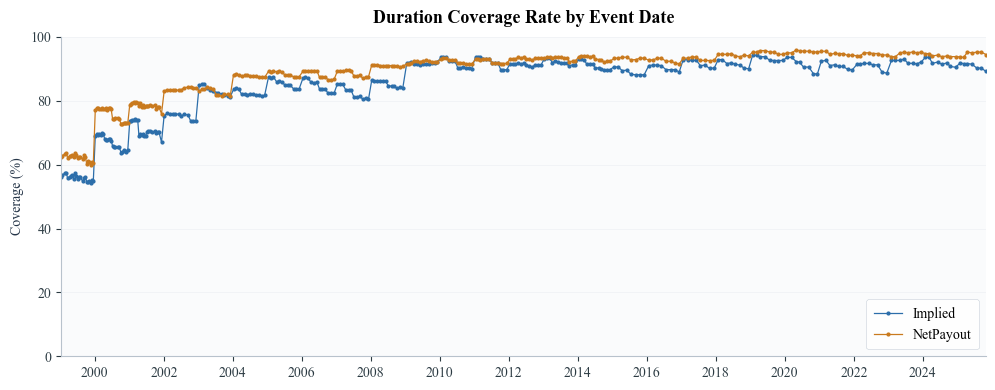

In [54]:
# Coverage diagnostic: share of event-firm obs with a valid duration
# Both Implied and NetPayout are annual → matched by year_pred = event_year - 1

cov_evt = df_evt[['event_date', 'date', 'firm_id', 'year_pred']].copy()
cov_evt['year_pred_int'] = pd.to_numeric(cov_evt['year_pred'], errors='coerce')

# Implied coverage
imp_yr = df_imp[['firm_id', 'year', 'implied_duration']].copy()
imp_yr['year'] = pd.to_numeric(imp_yr['year'], errors='coerce')
cov_evt = cov_evt.merge(
    imp_yr.rename(columns={'implied_duration': 'Duration_Implied'}),
    left_on=['firm_id', 'year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year'], errors='ignore')

# NetPayout coverage (same annual merge)
np_dur_col_cov = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=False, label='NetPayout duration for coverage'
)
if np_dur_col_cov:
    np_yr = df_np[['firm_id', 'year', np_dur_col_cov]].copy()
    np_yr['year'] = pd.to_numeric(np_yr['year'], errors='coerce')
    np_yr = np_yr.rename(columns={np_dur_col_cov: 'Duration_NetPayout'})
    cov_evt = cov_evt.merge(
        np_yr[['firm_id', 'year', 'Duration_NetPayout']],
        left_on=['firm_id', 'year_pred_int'],
        right_on=['firm_id', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')
else:
    cov_evt['Duration_NetPayout'] = np.nan

# Overall coverage summary
n = len(cov_evt)
cov_summary = pd.DataFrame({
    'Duration': ['Duration_Implied', 'Duration_NetPayout'],
    'N covered': [int(cov_evt['Duration_Implied'].notna().sum()),
                  int(cov_evt['Duration_NetPayout'].notna().sum())],
    'N total': [n, n],
    'Coverage %': [100 * cov_evt['Duration_Implied'].notna().mean(),
                   100 * cov_evt['Duration_NetPayout'].notna().mean()],
})
display(cov_summary.round(1))

# Coverage by event date
cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_Implied', 'Duration_NetPayout']]
    .agg(lambda s: s.notna().mean())
    .sort_values('event_date')
    .dropna(subset=['event_date'])
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_Implied'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='Implied', color=COLORS['blue'])
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_NetPayout'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='NetPayout', color=COLORS['orange'])
ax.set_title('Duration Coverage Rate by Event Date')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 100)
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_time_axis(ax, x_min=cov_by_event['event_date'].min(),
                x_max=cov_by_event['event_date'].max(),
                x_ticks=cov_by_event['event_date'], date_fmt='%Y')
style_legend(ax, loc='lower right')
plt.tight_layout()
fig.savefig(GRAPH_DIR / 'duration_coverage_by_event.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Define key variables

In [55]:
# ── Implied duration: annual firm-year panel → merge by firm_id + year_pred ──
_imp_rob_cols = [c for c in df_imp.columns if c.startswith('dur_')]
imp_feat = df_imp[['firm_id', 'year', 'implied_duration'] + _imp_rob_cols].copy()
imp_feat['year'] = pd.to_numeric(imp_feat['year'], errors='coerce')
imp_feat['Duration_Implied'] = pd.to_numeric(imp_feat['implied_duration'], errors='coerce')
_imp_rename = {c: f'Duration_Implied_{c[4:]}' for c in _imp_rob_cols}
imp_feat = imp_feat.rename(columns=_imp_rename)
_imp_variant_cols = list(_imp_rename.values())
imp_feat = imp_feat[['firm_id', 'year', 'Duration_Implied'] + _imp_variant_cols].dropna(subset=['Duration_Implied']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(
    imp_feat,
    left_on=['firm_id', '_year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year', '_year_pred_int'], errors='ignore')
print(f"Implied: {['Duration_Implied'] + _imp_variant_cols}")

# ── NetPayout duration: annual firm-year merge ────────────────────────────────
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=True, label='NetPayout duration'
)
np_feat = df_np[['firm_id', 'year', np_dur_col]].copy()
np_feat['year'] = pd.to_numeric(np_feat['year'], errors='coerce')
np_feat['Duration_NetPayout'] = pd.to_numeric(np_feat[np_dur_col], errors='coerce')
np_feat = np_feat[['firm_id', 'year', 'Duration_NetPayout']].dropna(subset=['Duration_NetPayout']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(
    np_feat,
    left_on=['firm_id', '_year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year', '_year_pred_int'], errors='ignore')
print(f"NetPayout: Duration_NetPayout")

# ── Controls ──────────────────────────────────────────────────────────────────
# beta    → already in df_evt from df_ret (rolling 36m CAPM beta)
# mcap_eur → already in df_evt from df_ret (Section 7 of euro500_IndexReturns.ipynb)
# log_mcap → computed here from mcap_eur
if 'mcap_eur' in df_evt.columns:
    df_evt['log_mcap'] = np.log(
        pd.to_numeric(df_evt['mcap_eur'], errors='coerce').clip(lower=1.0)
    )
    print(f"log_mcap computed from mcap_eur ({df_evt['log_mcap'].notna().mean():.1%} coverage)")
else:
    print("WARNING: mcap_eur not found in df_evt — run Section 7 of euro500_IndexReturns.ipynb first")

# leverage → from df_np annual panel (column: lev)
lev_col = first_existing(df_np, ['leverage', 'lev'], required=False, label='leverage')
if lev_col:
    lev_feat = df_np[['firm_id', 'year', lev_col]].copy()
    lev_feat['year'] = pd.to_numeric(lev_feat['year'], errors='coerce')
    lev_feat['leverage'] = pd.to_numeric(lev_feat[lev_col], errors='coerce')
    lev_feat = lev_feat[['firm_id', 'year', 'leverage']].dropna(subset=['leverage']).copy()
    df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
    df_evt = df_evt.merge(
        lev_feat,
        left_on=['firm_id', '_year_pred_int'],
        right_on=['firm_id', 'year'],
        how='left',
    ).drop(columns=['year', '_year_pred_int'], errors='ignore')
    print(f"leverage merged from df_np (col: {lev_col}, {df_evt['leverage'].notna().mean():.1%} coverage)")

print(f"\ndf_evt shape: {df_evt.shape}")

Implied: ['Duration_Implied', 'Duration_Implied_A_CAPM_r', 'Duration_Implied_B_dss_approx', 'Duration_Implied_C_rho_roe_hi', 'Duration_Implied_C_rho_roe_lo', 'Duration_Implied_D_rho_g_hi', 'Duration_Implied_D_rho_g_lo', 'Duration_Implied_E_gbar_emp', 'Duration_Implied_F_beg_fallback', 'Duration_Implied_H_tight_winsor']
NetPayout: Duration_NetPayout
log_mcap computed from mcap_eur (100.0% coverage)
leverage merged from df_np (col: lev, 93.3% coverage)

df_evt shape: (129510, 35)


## 4. Standardize variables

In [56]:
def zscore_by_year(df, col, year_col='year_pred'):
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_Implied': 'Duration_Implied_std',
    'Duration_NetPayout': 'Duration_NetPayout_std',
    'beta': 'beta_std',
    'log_mcap': 'log_mcap_std',
    'leverage': 'leverage_std',
    'bm': 'bm_std',
}

# Auto-add all implied duration robustness variants
for vc in [c for c in df_evt.columns if c.startswith('Duration_Implied_') and not c.endswith('_std')]:
    std_map[vc] = vc + '_std'

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]
display(df_evt[std_cols_present].describe().T[['mean', 'std', 'count']])

,mean,std,count
Duration_Implied_std,-1.686045e-17,1.000005,107885.0
Duration_NetPayout_std,2.415122e-17,1.000004,112975.0
beta_std,4.608826e-17,1.000004,123336.0
log_mcap_std,-3.230388e-16,1.000004,129510.0
leverage_std,3.010201e-17,1.000004,120855.0
Duration_Implied_A_CAPM_r_std,-1.686045e-17,1.000005,107885.0
Duration_Implied_B_dss_approx_std,1.348836e-16,1.000005,107885.0
Duration_Implied_C_rho_roe_hi_std,2.529067e-17,1.000005,107885.0
Duration_Implied_C_rho_roe_lo_std,1.180231e-16,1.000005,107885.0
Duration_Implied_D_rho_g_hi_std,8.430224e-17,1.000005,107885.0


## 5. Define regression helper functions

In [57]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False, controls=None):
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if 'bm' in controls:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    return f'{depvar} ~ 0 + {rhs}', terms

def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes, pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name, include_event_fe=False, include_raw_shocks=False, controls=None, cluster='event'):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar,
        duration_var=duration_var,
        include_event_fe=include_event_fe,
        include_raw_shocks=include_raw_shocks,
        controls=controls,
    )

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta' in controls:
        needed.append('beta_std')
    if 'size' in controls:
        needed.append('log_mcap_std')
    if 'leverage' in controls:
        needed.append('leverage_std')
    if 'bm' in controls:
        needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    mp_term = _coef_term('ShockMP', duration_var)
    info_term = _coef_term('ShockInfo', duration_var)
    beta_mp = 'ShockMP:beta_std'
    beta_info = 'ShockInfo:beta_std'
    size_mp = 'ShockMP:log_mcap_std'
    size_info = 'ShockInfo:log_mcap_std'
    lev_mp = 'ShockMP:leverage_std'
    lev_info = 'ShockInfo:leverage_std'

    row = {
        'depvar': depvar,
        'duration_name': duration_var,
        'specification_name': specification_name,
        'event_FE': 'Yes' if include_event_fe else 'No',
        'controls': _clean_controls_label(controls),
        'coef_mp_duration': _safe_get(res.params, mp_term),
        'se_mp_duration': _safe_get(res.bse, mp_term),
        't_mp_duration': _safe_get(res.tvalues, mp_term),
        'p_mp_duration': _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params, info_term),
        'se_info_duration': _safe_get(res.bse, info_term),
        't_info_duration': _safe_get(res.tvalues, info_term),
        'p_info_duration': _safe_get(res.pvalues, info_term),
        'coef_mp_beta': _safe_get(res.params, beta_mp),
        'coef_info_beta': _safe_get(res.params, beta_info),
        'coef_mp_size': _safe_get(res.params, size_mp),
        'coef_info_size': _safe_get(res.params, size_info),
        'coef_mp_leverage': _safe_get(res.params, lev_mp),
        'coef_info_leverage': _safe_get(res.params, lev_info),
        'N': int(res.nobs),
        'n_events': int(work['event_date'].nunique()),
        'r_squared': float(res.rsquared) if hasattr(res, 'rsquared') else np.nan,
        'model_obj': res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 6. Estimate main models

In [58]:
depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
duration_vars = [c for c in ['Duration_Implied_std', 'Duration_NetPayout_std'] if c in df_evt.columns]

controls_available = {
    'beta': 'beta_std' in df_evt.columns,
    'size': 'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm': 'bm_std' in df_evt.columns,
}

ctrl_beta = [c for c in ['beta'] if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

spec_grid = [
    {'name': 'Model 1: Basic two-shock interaction', 'event_fe': False, 'raw_shocks': False, 'controls': []},
    {'name': 'Model 2: + beta interactions', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_beta},
    {'name': 'Model 3: + size/leverage interactions (if available)', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 4: Event FE', 'event_fe': True, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 5: No Event FE (+ raw shocks)', 'event_fe': False, 'raw_shocks': True, 'controls': ctrl_plus},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt,
                depvar=dep,
                duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events', 'r_squared']])

,depvar,duration_name,specification_name,event_FE,controls,N,n_events,r_squared
0,AR_0,Duration_Implied_std,Model 1: Basic two-shock interaction,No,None,107885,312,0.000075
1,AR_0,Duration_Implied_std,Model 2: + beta interactions,No,beta,107493,312,0.005996
2,AR_0,Duration_Implied_std,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",106242,312,0.008943
3,AR_0,Duration_Implied_std,Model 4: Event FE,Yes,"beta, size, leverage",106242,312,0.087271
4,AR_0,Duration_Implied_std,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",106242,312,0.025988
5,AR_0,Duration_NetPayout_std,Model 1: Basic two-shock interaction,No,None,112975,312,0.000210
6,AR_0,Duration_NetPayout_std,Model 2: + beta interactions,No,beta,110321,312,0.006417
7,AR_0,Duration_NetPayout_std,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",110321,312,0.009475
8,AR_0,Duration_NetPayout_std,Model 4: Event FE,Yes,"beta, size, leverage",110321,312,0.088275
9,AR_0,Duration_NetPayout_std,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",110321,312,0.026382


## 7. Estimate robustness models

In [59]:
robust_rows = []

# ── Placebo 1: Pre-event day (AR_lag1) ───────────────────────────────────────
if 'AR_lag1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_lag1',
            duration_var=dur,
            specification_name='Placebo: Pre-event day (AR_lag1, Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_lag1 not found in df_evt — pre-event placebo skipped.')

# ── Placebo 2: 3-day window AR_m1_1 (includes event day) ─────────────────────
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_m1_1',
            duration_var=dur,
            specification_name='Robustness: 3-day window AR_m1_1 (Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

# ── Two-way clustering ────────────────────────────────────────────────────────
for dep in depvars_main:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=dur,
            specification_name='Robustness: Model 4 with two-way clustering',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='twoway',
        )
        if row is not None:
            robust_rows.append(row)

# ── Implied Duration specification robustness ─────────────────────────────────
# Run Model 4 (Event FE + controls) for each DSS robustness variant
_imp_variant_std_cols = sorted([
    c for c in df_evt.columns
    if c.startswith('Duration_Implied_') and c.endswith('_std')
])
print(f"\nTesting {len(_imp_variant_std_cols)} implied duration variants:")
for var_col in _imp_variant_std_cols:
    for dep in depvars_main:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=var_col,
            specification_name=f'DSS Variant: {var_col.replace("Duration_Implied_","").replace("_std","")}',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'N', 'n_events',
                        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
                        'coef_info_duration', 't_info_duration', 'p_info_duration']])

    # Summary table for DSS variants only
    dss_rob = df_robust[df_robust['specification_name'].str.startswith('DSS Variant')].copy()
    if not dss_rob.empty:
        print("\n── DSS Specification Robustness (Model 4, Event FE) ──")
        display(dss_rob[['depvar', 'duration_name', 'N',
                          'coef_mp_duration', 't_mp_duration',
                          'coef_info_duration', 't_info_duration']].round(4))
else:
    print('No robustness models estimated.')

/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning:


Testing 10 implied duration variants:


,depvar,duration_name,specification_name,N,n_events,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_lag1,Duration_Implied_std,"Placebo: Pre-event day (AR_lag1, Event FE)",105948,312,-0.002165,-0.517464,0.604832,0.003546,0.738886,0.459976
1,AR_lag1,Duration_NetPayout_std,"Placebo: Pre-event day (AR_lag1, Event FE)",110007,312,-0.004997,-1.352082,0.176349,0.003941,0.820775,0.411774
2,AR_m1_1,Duration_Implied_std,Robustness: 3-day window AR_m1_1 (Event FE),105276,312,0.002385,0.399635,0.689425,0.007573,0.877389,0.380276
3,AR_m1_1,Duration_NetPayout_std,Robustness: 3-day window AR_m1_1 (Event FE),109309,312,-0.002288,-0.325152,0.745066,0.012865,1.508343,0.131467
4,AR_0,Duration_Implied_std,Robustness: Model 4 with two-way clustering,106242,312,-0.000735,-0.166168,0.868025,0.004629,0.970364,0.331865
5,AR_0,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,110321,312,-0.002730,-0.645014,0.518918,0.010091,1.696631,0.089766
6,AR_0_1,Duration_Implied_std,Robustness: Model 4 with two-way clustering,105570,312,0.004134,0.557697,0.577051,0.004823,0.677558,0.498052
7,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,109623,312,0.002231,0.351809,0.724981,0.010170,1.573990,0.115490
8,AR_0,Duration_Implied_A_CAPM_r_std,DSS Variant: A_CAPM_r,106242,312,-0.000735,-0.159464,0.873303,0.004629,1.063775,0.287430
9,AR_0_1,Duration_Implied_A_CAPM_r_std,DSS Variant: A_CAPM_r,105570,312,0.004134,0.540688,0.588723,0.004823,0.713892,0.475294



── DSS Specification Robustness (Model 4, Event FE) ──


,depvar,duration_name,N,coef_mp_duration,t_mp_duration,coef_info_duration,t_info_duration
8,AR_0,Duration_Implied_A_CAPM_r_std,106242,-0.0007,-0.1595,0.0046,1.0638
9,AR_0_1,Duration_Implied_A_CAPM_r_std,105570,0.0041,0.5407,0.0048,0.7139
10,AR_0,Duration_Implied_B_dss_approx_std,106242,-0.0005,-0.1061,0.0044,1.0302
11,AR_0_1,Duration_Implied_B_dss_approx_std,105570,0.0044,0.5746,0.0043,0.6427
12,AR_0,Duration_Implied_C_rho_roe_hi_std,106242,-0.0020,-0.4936,0.0038,0.9754
13,AR_0_1,Duration_Implied_C_rho_roe_hi_std,105570,0.0027,0.4014,0.0019,0.3229
14,AR_0,Duration_Implied_C_rho_roe_lo_std,106242,0.0009,0.1867,0.0056,1.1621
15,AR_0_1,Duration_Implied_C_rho_roe_lo_std,105570,0.0058,0.7047,0.0087,1.1924
16,AR_0,Duration_Implied_D_rho_g_hi_std,106242,0.0017,0.3128,0.0038,0.8967
17,AR_0_1,Duration_Implied_D_rho_g_hi_std,105570,0.0061,0.7590,0.0048,0.7167


## 8. Build tidy results tables

In [60]:
def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration'] = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE'] = tbl['event_FE']
tbl['Controls'] = tbl['controls']

fmt_cols = ['coef_mp_duration', 't_mp_duration', 'p_mp_duration', 'coef_info_duration', 't_info_duration', 'p_info_duration']
for c in fmt_cols:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events'
]

col_rename = {
    'coef_mp_duration': 'ShockMP × Duration',
    't_mp_duration': 't-stat MP',
    'p_mp_duration': 'p-value MP',
    'coef_info_duration': 'ShockInfo × Duration',
    't_info_duration': 't-stat Info',
    'p_info_duration': 'p-value Info',
    'n_events': 'Events',
}

# TABLE A: Baseline (event-day return)
TABLE_A = tbl[tbl['depvar'] == 'AR_0'][table_cols].rename(columns=col_rename)

# TABLE B: Robustness (two-day return)
TABLE_B = tbl[tbl['depvar'] == 'AR_0_1'][table_cols].rename(columns=col_rename)

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP × Duration', 't-stat MP', 'p-value MP', 'ShockInfo × Duration', 't-stat Info', 'p-value Info']:
        _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

reader = tbl.copy()
reader['ShockMP × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']), axis=1)
reader['ShockInfo × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls', 'ShockMP × Duration', 'ShockInfo × Duration', 'N', 'n_events']].rename(columns={'depvar': 'Return window', 'n_events': 'Events'})

print('TABLE A: Main results for AR_0 (baseline: event-day return)')
display(TABLE_A)
print('TABLE B: Robustness for AR_0_1 (two-day return)')
display(TABLE_B)
print('Reader table (coef*** (t-stat))')
display(TABLE_READER)

TABLE A: Main results for AR_0 (baseline: event-day return)


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
0,Implied,Model 1: Basic two-shock interaction,No,None,0.0032,0.4711,0.6376,0.0057,1.0505,0.2935,107885,312
1,Implied,Model 2: + beta interactions,No,beta,0.0019,0.2630,0.7925,0.0093,1.6943,0.0902,107493,312
2,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",-0.0012,-0.2677,0.7889,0.0052,1.2066,0.2276,106242,312
3,Implied,Model 4: Event FE,Yes,"beta, size, leverage",-0.0007,-0.1595,0.8733,0.0046,1.0638,0.2874,106242,312
4,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",-0.0007,-0.1492,0.8814,0.0045,1.0304,0.3028,106242,312
5,NetPayout,Model 1: Basic two-shock interaction,No,None,0.0011,0.1697,0.8653,0.0115,1.7270,0.0842,112975,312
6,NetPayout,Model 2: + beta interactions,No,beta,-0.0005,-0.0669,0.9466,0.0160,2.3987,0.0165,110321,312
7,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",-0.0043,-1.0205,0.3075,0.0112,2.1180,0.0342,110321,312
8,NetPayout,Model 4: Event FE,Yes,"beta, size, leverage",-0.0027,-0.6356,0.5250,0.0101,1.9344,0.0531,110321,312
9,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",-0.0030,-0.6908,0.4897,0.0097,1.8517,0.0641,110321,312


TABLE B: Robustness for AR_0_1 (two-day return)


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
10,Implied,Model 1: Basic two-shock interaction,No,None,0.0075,0.7752,0.4382,0.0049,0.6005,0.5482,107191,312
11,Implied,Model 2: + beta interactions,No,beta,0.0058,0.5757,0.5648,0.0084,1.0354,0.3005,106809,312
12,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",0.0040,0.5273,0.5980,0.0052,0.7765,0.4374,105570,312
13,Implied,Model 4: Event FE,Yes,"beta, size, leverage",0.0041,0.5407,0.5887,0.0048,0.7139,0.4753,105570,312
14,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",0.0044,0.5840,0.5592,0.0046,0.6808,0.4960,105570,312
15,NetPayout,Model 1: Basic two-shock interaction,No,None,0.0050,0.5625,0.5738,0.0100,1.1538,0.2486,112230,312
16,NetPayout,Model 2: + beta interactions,No,beta,0.0037,0.3862,0.6993,0.0150,1.7577,0.0788,109623,312
17,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",0.0006,0.0963,0.9233,0.0110,1.7204,0.0854,109623,312
18,NetPayout,Model 4: Event FE,Yes,"beta, size, leverage",0.0022,0.3475,0.7282,0.0102,1.6199,0.1053,109623,312
19,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",0.0017,0.2632,0.7924,0.0097,1.5446,0.1225,109623,312


Reader table (coef*** (t-stat))


,Return window,Duration,Specification,Event FE,Controls,ShockMP × Duration,ShockInfo × Duration,N,Events
0,AR_0,Implied,Model 1: Basic two-shock interaction,No,None,0.0032 (0.47),0.0057 (1.05),107885,312
1,AR_0,Implied,Model 2: + beta interactions,No,beta,0.0019 (0.26),0.0093* (1.69),107493,312
2,AR_0,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",-0.0012 (-0.27),0.0052 (1.21),106242,312
3,AR_0,Implied,Model 4: Event FE,Yes,"beta, size, leverage",-0.0007 (-0.16),0.0046 (1.06),106242,312
4,AR_0,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",-0.0007 (-0.15),0.0045 (1.03),106242,312
5,AR_0,NetPayout,Model 1: Basic two-shock interaction,No,None,0.0011 (0.17),0.0115* (1.73),112975,312
6,AR_0,NetPayout,Model 2: + beta interactions,No,beta,-0.0005 (-0.07),0.0160** (2.40),110321,312
7,AR_0,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, size, leverage",-0.0043 (-1.02),0.0112** (2.12),110321,312
8,AR_0,NetPayout,Model 4: Event FE,Yes,"beta, size, leverage",-0.0027 (-0.64),0.0101* (1.93),110321,312
9,AR_0,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, size, leverage",-0.0030 (-0.69),0.0097* (1.85),110321,312


## 8b. Side-by-side comparison tables

In [61]:
compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE', 'coef_mp_duration', 'coef_info_duration', 't_mp_duration', 't_info_duration']].copy()
compact['mp_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], np.nan), axis=1)
compact['info_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], np.nan), axis=1)

# Comparison 1: Implied vs NetPayout (baseline: AR_0)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'], columns='duration_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 2: AR_0 (baseline) vs AR_0_1 (robustness) — same duration, same specification
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'], columns='depvar', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 3: Event FE vs No Event FE (Model 4 vs Model 5)
cmp3_base = compact[compact['specification_name'].isin(['Model 4: Event FE', 'Model 5: No Event FE (+ raw shocks)'])].copy()
CMP_3 = (
    cmp3_base
    .pivot_table(index=['depvar', 'duration_name'], columns='specification_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: Implied vs NetPayout (AR_0, baseline)')
display(CMP_1)
print('Comparison Table 2: AR_0 (baseline) vs AR_0_1 (robustness)')
display(CMP_2)
print('Comparison Table 3: Event FE vs No Event FE')
display(CMP_3)

Comparison Table 1: Implied vs NetPayout (AR_0, baseline)


info_reader                                   mp_reader                       
duration_name                                                      Duration_Implied_std Duration_NetPayout_std Duration_Implied_std Duration_NetPayout_std
depvar specification_name                                 event_FE                                                                                        
AR_0   Model 1: Basic two-shock interaction               No              0.0057 (1.05)          0.0115 (1.73)        0.0032 (0.47)          0.0011 (0.17)
       Model 2: + beta interactions                       No              0.0093 (1.69)          0.0160 (2.40)        0.0019 (0.26)        -0.0005 (-0.07)
       Model 3: + size/leverage interactions (if avail... No              0.0052 (1.21)          0.0112 (2.12)      -0.0012 (-0.27)        -0.0043 (-1.02)
       Model 4: Event FE                                  Yes             0.0046 (1.06)          0.0101 (1.93)      -0.0007 (-0.16)        -0.0027 (-0.64)
       Model 5: No Event FE (+ raw shocks)                No              0.0045 (1.03)          0.0097 (1.85)      -0.0007 (-0.15)        -0.0030 (-0.69)

Comparison Table 2: AR_0 (baseline) vs AR_0_1 (robustness)


info_reader                       mp_reader               
depvar                                                                                       AR_0         AR_0_1             AR_0         AR_0_1
duration_name          specification_name                                 event_FE                                                              
Duration_Implied_std   Model 1: Basic two-shock interaction               No        0.0057 (1.05)  0.0049 (0.60)    0.0032 (0.47)  0.0075 (0.78)
                       Model 2: + beta interactions                       No        0.0093 (1.69)  0.0084 (1.04)    0.0019 (0.26)  0.0058 (0.58)
                       Model 3: + size/leverage interactions (if avail... No        0.0052 (1.21)  0.0052 (0.78)  -0.0012 (-0.27)  0.0040 (0.53)
                       Model 4: Event FE                                  Yes       0.0046 (1.06)  0.0048 (0.71)  -0.0007 (-0.16)  0.0041 (0.54)
                       Model 5: No Event FE (+ raw shocks)                No        0.0045 (1.03)  0.0046 (0.68)  -0.0007 (-0.15)  0.0044 (0.58)
Duration_NetPayout_std Model 1: Basic two-shock interaction               No        0.0115 (1.73)  0.0100 (1.15)    0.0011 (0.17)  0.0050 (0.56)
                       Model 2: + beta interactions                       No        0.0160 (2.40)  0.0150 (1.76)  -0.0005 (-0.07)  0.0037 (0.39)
                       Model 3: + size/leverage interactions (if avail... No        0.0112 (2.12)  0.0110 (1.72)  -0.0043 (-1.02)  0.0006 (0.10)
                       Model 4: Event FE                                  Yes       0.0101 (1.93)  0.0102 (1.62)  -0.0027 (-0.64)  0.0022 (0.35)
                       Model 5: No Event FE (+ raw shocks)                No        0.0097 (1.85)  0.0097 (1.54)  -0.0030 (-0.69)  0.0017 (0.26)

Comparison Table 3: Event FE vs No Event FE


info_reader                                             mp_reader                                    
specification_name            Model 4: Event FE Model 5: No Event FE (+ raw shocks) Model 4: Event FE Model 5: No Event FE (+ raw shocks)
depvar duration_name                                                                                                                     
AR_0   Duration_Implied_std       0.0046 (1.06)                       0.0045 (1.03)   -0.0007 (-0.16)                     -0.0007 (-0.15)
       Duration_NetPayout_std     0.0101 (1.93)                       0.0097 (1.85)   -0.0027 (-0.64)                     -0.0030 (-0.69)
AR_0_1 Duration_Implied_std       0.0048 (0.71)                       0.0046 (0.68)     0.0041 (0.54)                       0.0044 (0.58)
       Duration_NetPayout_std     0.0102 (1.62)                       0.0097 (1.54)     0.0022 (0.35)                       0.0017 (0.26)

## 9. Create coefficient plots

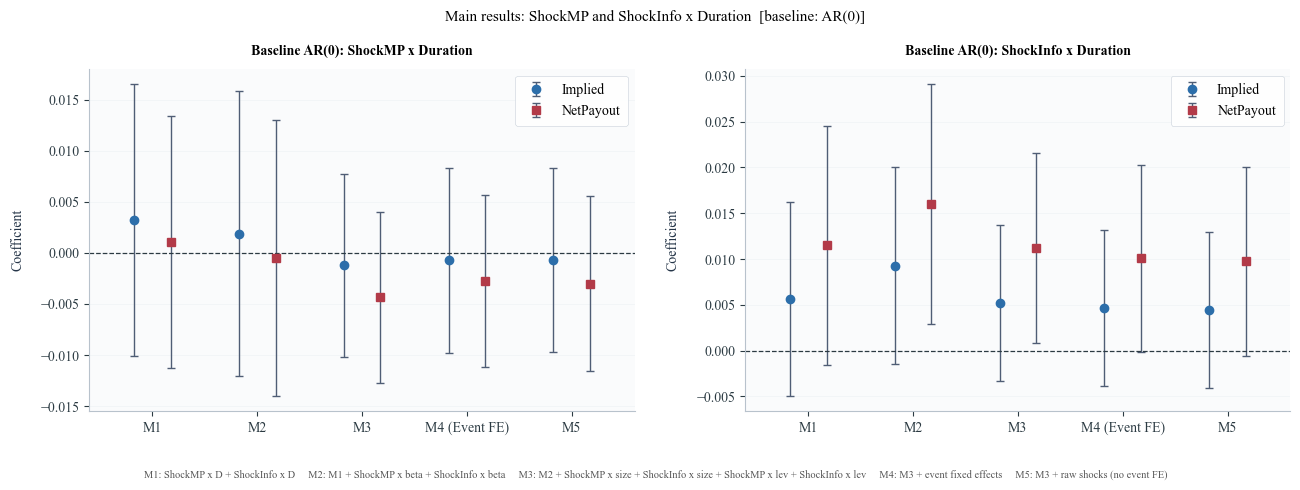

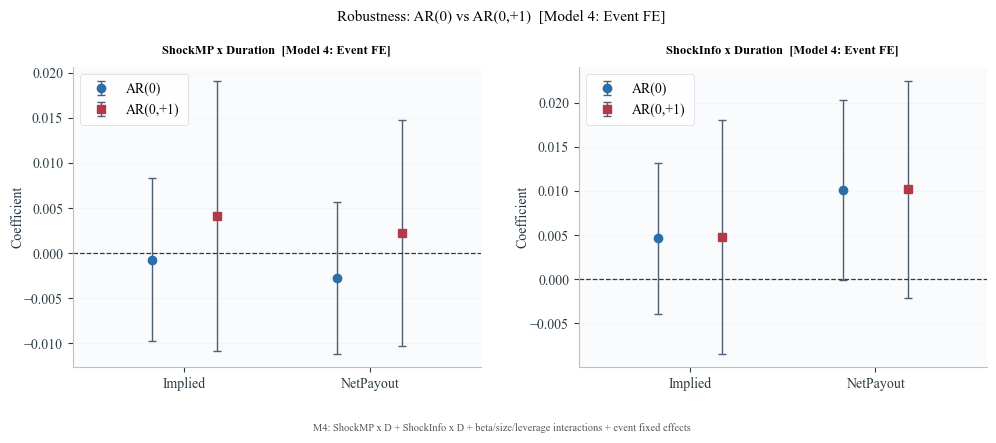

In [62]:
plot_df = df_results.copy()

duration_order_map = {
    'Duration_Implied_std': 0,
    'Duration_NetPayout_std': 1,
}
depvar_order_map = {
    'AR_0': 0,
    'AR_0_1': 1,
}
spec_order_map = {
    'Model 1: Basic two-shock interaction': 0,
    'Model 2: + beta interactions': 1,
    'Model 3: + size/leverage interactions (if available)': 2,
    'Model 4: Event FE': 3,
    'Model 5: No Event FE (+ raw shocks)': 4,
}

spec_short = {
    'Model 1: Basic two-shock interaction': 'M1',
    'Model 2: + beta interactions': 'M2',
    'Model 3: + size/leverage interactions (if available)': 'M3',
    'Model 4: Event FE': 'M4 (Event FE)',
    'Model 5: No Event FE (+ raw shocks)': 'M5',
}
dur_short = {
    'Duration_Implied_std': 'Implied',
    'Duration_NetPayout_std': 'NetPayout',
}
dep_short = {
    'AR_0':   'AR(0)',
    'AR_0_1': 'AR(0,+1)',
}

MODEL_NOTE = (
    'M1: ShockMP x D + ShockInfo x D     '
    'M2: M1 + ShockMP x beta + ShockInfo x beta     '
    'M3: M2 + ShockMP x size + ShockInfo x size + ShockMP x lev + ShockInfo x lev     '
    'M4: M3 + event fixed effects     '
    'M5: M3 + raw shocks (no event FE)'
)

# ── Main plot: Baseline AR_0, side-by-side Implied vs NetPayout ───────────────
main_df = plot_df[plot_df['depvar'] == 'AR_0'].copy()
main_df['spec_order'] = main_df['specification_name'].map(spec_order_map).fillna(99)
main_df = main_df.sort_values('spec_order')
specs = main_df['specification_name'].unique()
x = np.arange(len(specs))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.subplots_adjust(bottom=0.22)

for ax, coef_col, se_col, shock_label, color_imp, color_np in [
    (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration',   COLORS['blue'],   COLORS['accent']),
    (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration', COLORS['blue'],   COLORS['accent']),
]:
    for dur, offset, color, marker in [
        ('Duration_Implied_std',   -w/2, color_imp, 'o'),
        ('Duration_NetPayout_std',  w/2, color_np,  's'),
    ]:
        d = main_df[main_df['duration_name'] == dur].set_index('specification_name').reindex(specs)
        coefs = pd.to_numeric(d[coef_col], errors='coerce')
        ses   = pd.to_numeric(d[se_col],   errors='coerce')
        ax.errorbar(
            x + offset, coefs,
            yerr=1.96 * ses,
            fmt=marker, color=color, ecolor=COLORS['neutral'],
            capsize=3, markersize=6,
            label=dur_short[dur],
        )
    ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([spec_short[s] for s in specs], fontsize=9)
    ax.set_xlim(-0.6, len(specs) - 0.4)
    ax.set_title(f'Baseline AR(0): {shock_label}', fontsize=10)
    ax.set_ylabel('Coefficient')
    style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
    style_legend(ax, loc='best')

fig.text(0.5, 0.04, MODEL_NOTE, ha='center', va='bottom', fontsize=7.5,
         color='#555555', wrap=True)
plt.suptitle('Main results: ShockMP and ShockInfo x Duration  [baseline: AR(0)]', fontsize=11)
plt.tight_layout(rect=[0, 0.10, 1, 1], w_pad=3)
plt.show()

# ── Robustness plot: AR(0) vs AR(0,+1), Model 4 only ─────────────────────────
rob_df = plot_df[plot_df['specification_name'] == 'Model 4: Event FE'].copy()
dur_list = ['Duration_Implied_std', 'Duration_NetPayout_std']
x2 = np.arange(len(dur_list))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)
fig.subplots_adjust(bottom=0.22)

for ax, coef_col, se_col, title in [
    (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration  [Model 4: Event FE]'),
    (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration  [Model 4: Event FE]'),
]:
    for dep, offset, color, marker in [
        ('AR_0',   -w/2, COLORS['blue'],   'o'),
        ('AR_0_1',  w/2, COLORS['accent'], 's'),
    ]:
        d = rob_df[rob_df['depvar'] == dep].set_index('duration_name').reindex(dur_list)
        ax.errorbar(
            x2 + offset,
            pd.to_numeric(d[coef_col], errors='coerce'),
            yerr=1.96 * pd.to_numeric(d[se_col], errors='coerce'),
            fmt=marker, color=color, ecolor=COLORS['neutral'],
            capsize=3, markersize=6,
            label=dep_short[dep],
        )
    ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
    ax.set_xticks(x2)
    ax.set_xticklabels([dur_short[d] for d in dur_list])
    ax.set_xlim(-0.6, len(dur_list) - 0.4)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('Coefficient')
    style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
    style_legend(ax, loc='best')

fig.text(0.5, 0.04, 'M4: ShockMP x D + ShockInfo x D + beta/size/leverage interactions + event fixed effects',
         ha='center', va='bottom', fontsize=7.5, color='#555555')
plt.suptitle('Robustness: AR(0) vs AR(0,+1)  [Model 4: Event FE]', fontsize=11)
plt.tight_layout(rect=[0, 0.10, 1, 1], w_pad=3)
plt.show()

## 10. Export output tables

In [63]:
# Wald tests: H0 beta(ShockMP x Duration) = beta(ShockInfo x Duration)
wald_rows = []
for _, r in df_results.iterrows():
    res = r['model_obj']
    dur = r['duration_name']
    mp_term = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue

    R = np.zeros((1, len(res.params)))
    names = list(res.params.index)
    R[0, names.index(mp_term)] = 1.0
    R[0, names.index(info_term)] = -1.0
    wt = res.wald_test(R, scalar=True)

    beta_mp = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration': dur.replace('_std', '').replace('Duration_', ''),
        'Return window': r['depvar'],
        'Specification': r['specification_name'],
        'beta_MP': beta_mp,
        'beta_Info': beta_info,
        'difference': beta_mp - beta_info,
        'Wald p-value': float(wt.pvalue),
    })

regression_results_main = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald = pd.DataFrame(wald_rows)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)

# Optional LaTeX export
latex_cols = [
    'depvar', 'duration_name', 'specification_name', 'event_FE', 'controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'r_squared'
]
regression_results_main[latex_cols].to_latex(TABLE_DIR / 'regression_results_main.tex', index=False, float_format='%.4f')

print('Exported:')
print(TABLE_DIR / 'regression_results_main.csv')
print(TABLE_DIR / 'regression_results_reader.csv')
print(TABLE_DIR / 'regression_results_wald.csv')
print(TABLE_DIR / 'regression_results_main.tex')

Exported:
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_reader.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_wald.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.tex


## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.